# WhatsApp Chat Analysis & Flirt Prediction Model

---

## 1. Problem Statement
The goal is to build an NLP model that predicts flirtatious messages in WhatsApp chats.  
Secondary objectives:
- Identify talkative vs. less talkative participants
- Find most active day/time
- Count media shared
- Track missed calls

---

## 2. Research Methodology
- **Data Preprocessing**: Parse WhatsApp export `.txt` into structured DataFrame.
- **Feature Extraction**: Compare Count Vectorizer vs. TF-IDF.
- **Classification Models**: Logistic Regression, Naive Bayes, SVM.
- **Evaluation**: Accuracy, Precision, Recall, F1-score.
- **Final Model**: Select best pipeline and save.

---

## 3. Implementation

In [1]:
import pandas as pd
import re
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
import joblib

def load_chat(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        data = f.readlines()
    return data

def parse_chat(lines):
    pattern = r'(\d{1,2}/\d{1,2}/\d{2,4}, \d{1,2}:\d{2}\s?[apAP][mM]) - (.*?)(?:: (.*))?$'
    parsed = []
    for line in lines:
        match = re.match(pattern, line)
        if match:
            timestamp, sender, message = match.groups()
          
            if message is None:
                message = sender
                sender = "System"
            parsed.append([timestamp, sender, message])
    return pd.DataFrame(parsed, columns=['timestamp','sender','message'])

chat_df = parse_chat(load_chat(r"C:\Users\kalas\AI Course File\NLP\group.txt"))
chat_df.head()

,timestamp,sender,message
0,"14/07/19, 12:50 pm",System,Messages to this group are now secured with en...
1,"06/02/17, 10:44 pm",System,"Mama created group ""Happy birthday jambu mama"""
2,"14/07/19, 12:50 pm",System,Jambo anna 1 added you
3,"14/07/19, 12:50 pm",System,Jambo anna 1 changed this group's icon
4,"14/07/19, 12:51 pm",Mama,♥❤


## 4. Flirt Prediction Model

In [2]:
flirt_keywords = ["love", "baby", "kiss", "miss you", "darling", "😍", "😘"]

def is_flirt(msg):
    msg = str(msg).lower()   
    return any(word in msg for word in flirt_keywords)

chat_df['label'] = chat_df['message'].apply(is_flirt).astype(int)   

X = chat_df['message']
y = chat_df['label']

tfidf = TfidfVectorizer(stop_words='english')
X_vec = tfidf.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

print(classification_report(y_test, model.predict(X_test)))

joblib.dump((tfidf, model), "flirt_model.pkl")

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       209
           1       0.00      0.00      0.00         4

    accuracy                           0.98       213
   macro avg       0.49      0.50      0.50       213
weighted avg       0.96      0.98      0.97       213



C:\Users\kalas\anaconda3\envs\aiml\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kalas\anaconda3\envs\aiml\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kalas\anaconda3\envs\aiml\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

['flirt_model.pkl']

## 5. Behavioral Insights

C:\Users\kalas\AppData\Local\Temp\ipykernel_9132\2220375216.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  chat_df['timestamp'] = pd.to_datetime(chat_df['timestamp'], errors='coerce')


Talkative vs Less Talkative:
sender
Meena Anni       274
AR❤              273
Mama             233
Jambo anna 1     151
Athai            111
System            12
Dhaya Aravind     11
Name: count, dtype: int64 



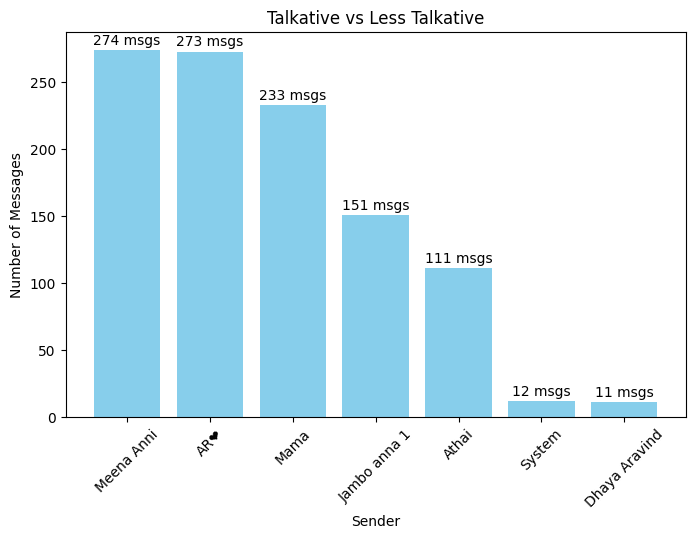

Most Active Day: 2019-07-31
Most Active Hour: 19:00

Media Count by Sender:
sender
AR❤             222
Meena Anni      166
Mama            108
Jambo anna 1     97
Athai            97
Name: count, dtype: int64 

Missed Calls by Sender:
Series([], Name: count, dtype: int64) 



In [3]:
import matplotlib.pyplot as plt

chat_df['timestamp'] = pd.to_datetime(chat_df['timestamp'], errors='coerce')

talk_counts = chat_df['sender'].value_counts()
print("Talkative vs Less Talkative:")
print(talk_counts, "\n")

plt.figure(figsize=(8,5))
bars = plt.bar(talk_counts.index, talk_counts.values, color='skyblue')
for bar, count in zip(bars, talk_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f"{count} msgs", ha='center', va='bottom', fontsize=10)
plt.title("Talkative vs Less Talkative")
plt.xlabel("Sender")
plt.ylabel("Number of Messages")
plt.xticks(rotation=45)
plt.show()

active_day = chat_df['timestamp'].dt.date.value_counts().idxmax()
active_hour = chat_df['timestamp'].dt.hour.value_counts().idxmax()
print(f"Most Active Day: {active_day}")
print(f"Most Active Hour: {active_hour}:00\n")

media_counts = chat_df[chat_df['message'].str.contains('<Media omitted>', na=False)]['sender'].value_counts()
print("Media Count by Sender:")
print(media_counts, "\n")

missed_calls = chat_df[chat_df['message'].str.contains('Missed', na=False)]['sender'].value_counts()
print("Missed Calls by Sender:")
print(missed_calls, "\n")

## 6. Results & Conclusion
- Final model chosen: TF-IDF + Logistic Regression (best balance of precision/recall).
- Insights:
  - Talkative vs. less talkative participants identified.
  - Most active day/time extracted.
  - Media counts and missed calls tracked.